# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd

Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

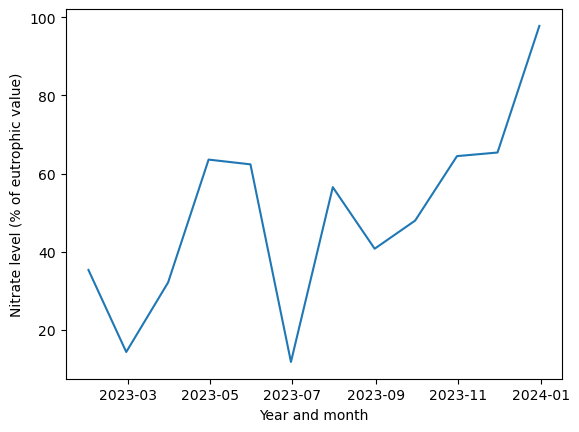

In [2]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

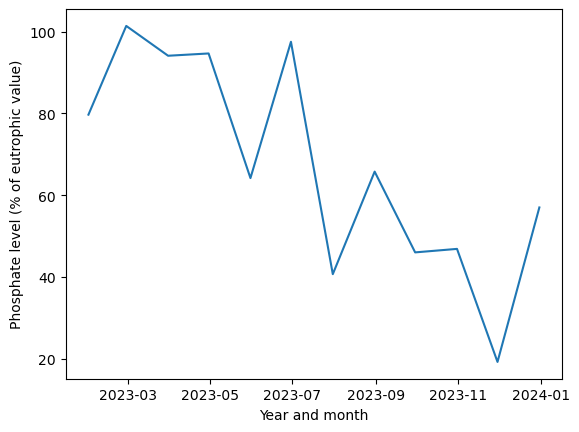

In [3]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<Axes: >

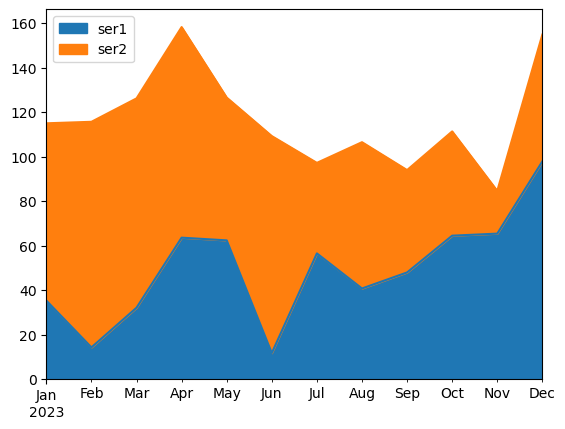

In [4]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

Dataset downloaded to: /Users/rajevasan/.cache/kagglehub/datasets/laotse/credit-risk-dataset/versions/1
Available files: ['credit_risk_dataset.csv']
=== How many rows and columns? ===
(32581, 12)

=== First 5 rows ===
   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     ME

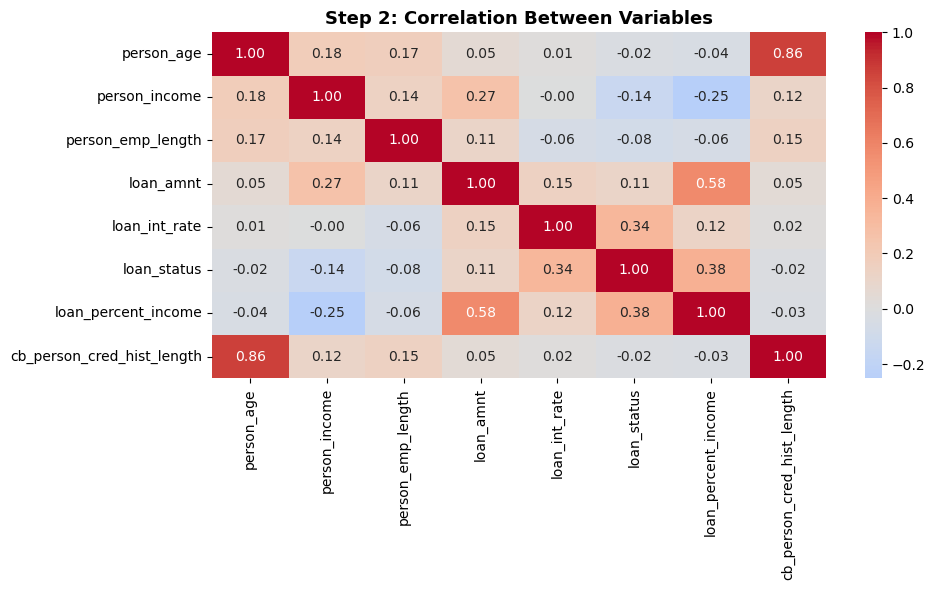

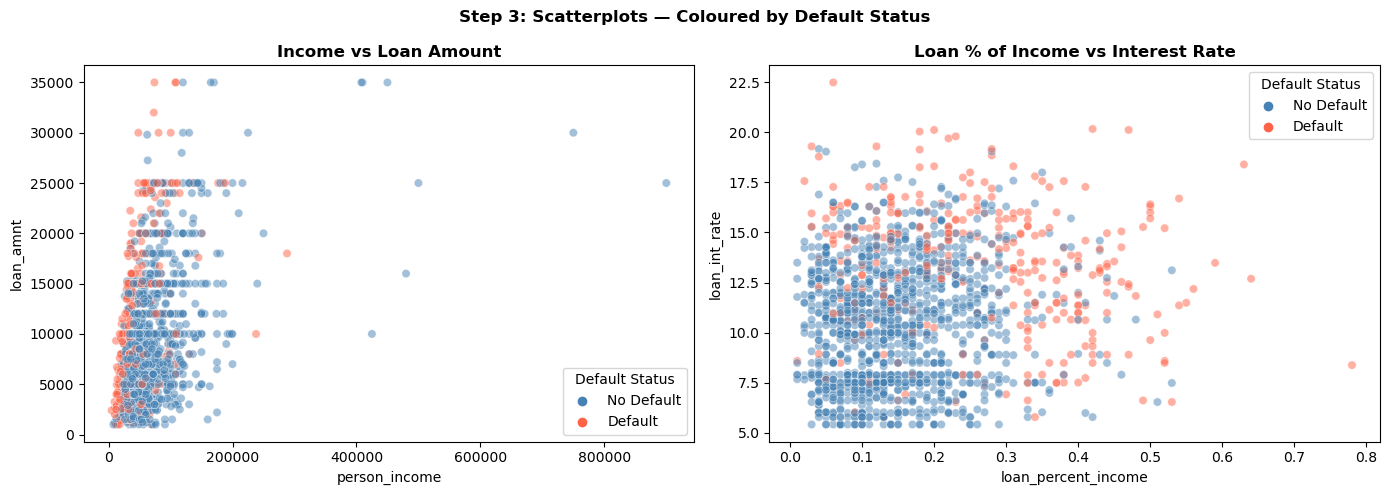

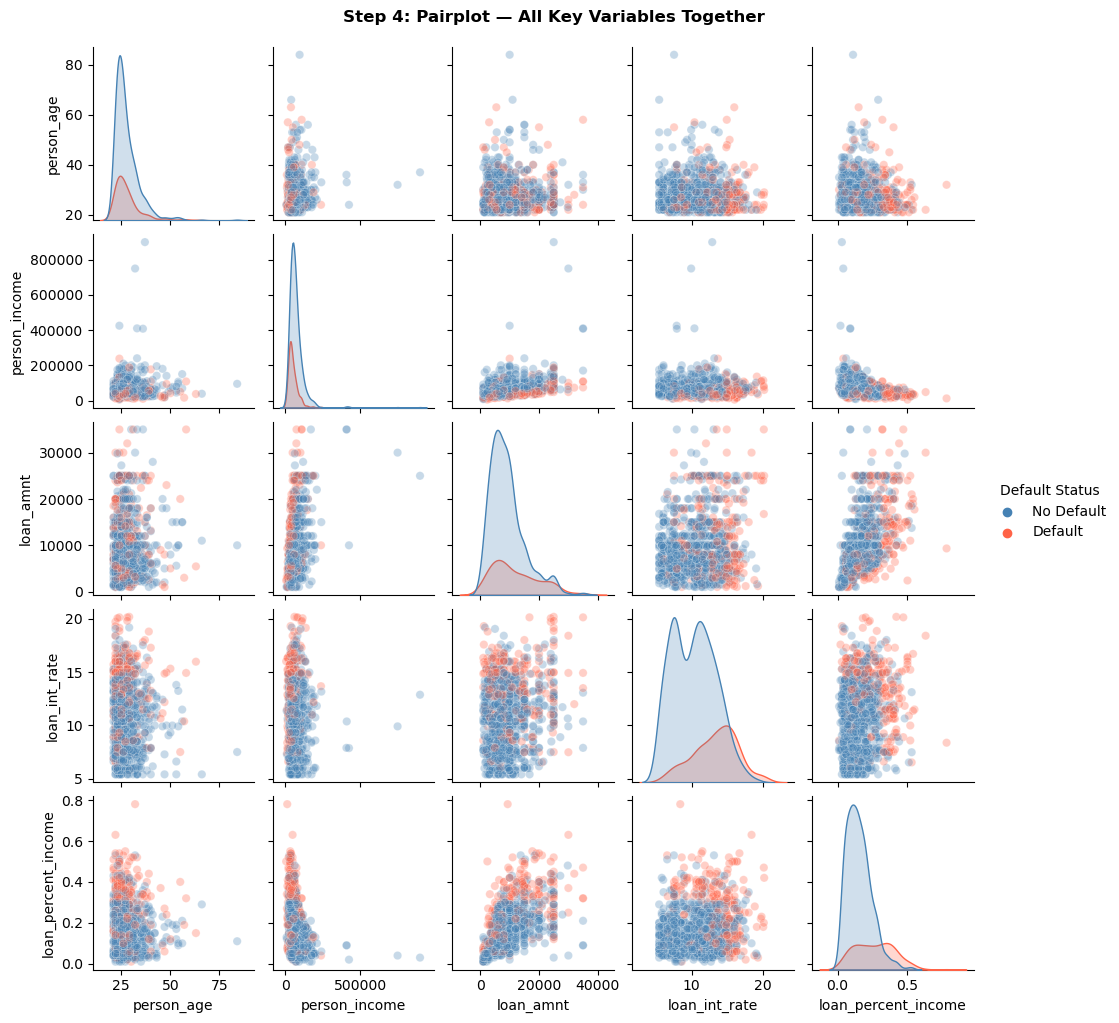

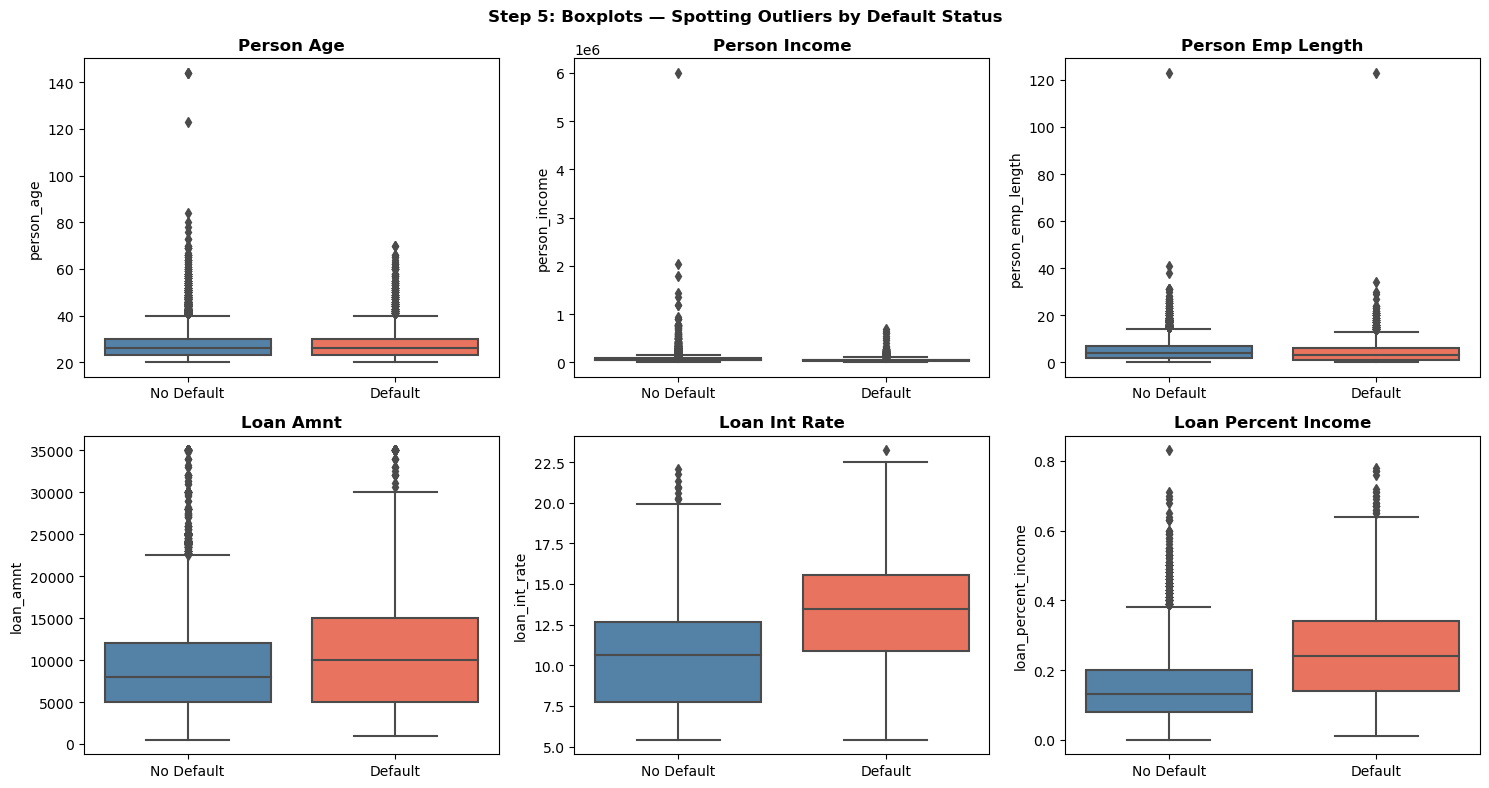

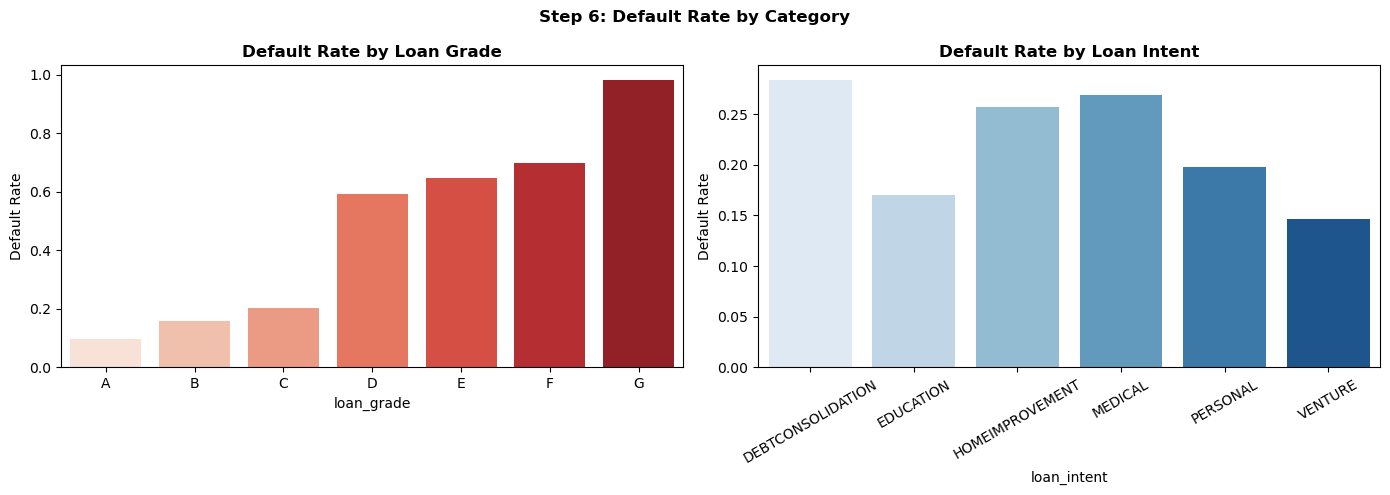


=== All done! ===


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import kagglehub
warnings.filterwarnings('ignore')

# ── STEP 1: Load the data ─────────────────────────────────────────────────────
# Dataset: https://www.kaggle.com/datasets/laotse/credit-risk-dataset

path = kagglehub.dataset_download("laotse/credit-risk-dataset")
print("Dataset downloaded to:", path)

files = os.listdir(path)
print("Available files:", files)

csv_file = os.path.join(path, files[0])
df = pd.read_csv(csv_file)

print("=== How many rows and columns? ===")
print(df.shape)

print("\n=== First 5 rows ===")
print(df.head())

print("\n=== Any missing values? ===")
print(df.isnull().sum())

print("\n=== Basic stats ===")
print(df.describe().round(2))

print("\n=== How many defaulted vs not? ===")
print(df['loan_status'].value_counts())
print(df['loan_status'].value_counts(normalize=True).round(2))

# ── Fix: drop rows with NaNs in key columns used in plots ────────────────────
df_clean = df.dropna(subset=['loan_int_rate', 'person_emp_length']).copy()

# ── Fix: map loan_status to readable labels directly ─────────────────────────
# Using a label column avoids ALL palette ordering issues
df_clean['Default Status'] = df_clean['loan_status'].map({0: 'No Default', 1: 'Default'})

PALETTE   = {'No Default': 'steelblue', 'Default': 'tomato'}
HUE_ORDER = ['No Default', 'Default']   # always renders in this exact order

# ── STEP 2: Correlation heatmap ───────────────────────────────────────────────
plt.figure(figsize=(10, 6))
numeric_cols = df_clean.select_dtypes(include='number')
corr = numeric_cols.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Step 2: Correlation Between Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── STEP 3: Scatterplots ──────────────────────────────────────────────────────
plot_sample = df_clean.sample(1500, random_state=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Income vs Loan Amount
sns.scatterplot(data=plot_sample,
                x='person_income', y='loan_amnt',
                hue='Default Status',
                hue_order=HUE_ORDER,
                palette=PALETTE,
                alpha=0.5, ax=axes[0])
axes[0].set_title('Income vs Loan Amount', fontweight='bold')

# Plot 2: Loan % of Income vs Interest Rate
sns.scatterplot(data=plot_sample,
                x='loan_percent_income', y='loan_int_rate',
                hue='Default Status',
                hue_order=HUE_ORDER,
                palette=PALETTE,
                alpha=0.5, ax=axes[1])
axes[1].set_title('Loan % of Income vs Interest Rate', fontweight='bold')

plt.suptitle('Step 3: Scatterplots — Coloured by Default Status',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── STEP 4: Pairplot ──────────────────────────────────────────────────────────
cols = ['person_age', 'person_income', 'loan_amnt', 'loan_int_rate',
        'loan_percent_income', 'Default Status']
sample = df_clean[cols].sample(1000, random_state=1).copy()

g = sns.pairplot(sample,
                 hue='Default Status',
                 hue_order=HUE_ORDER,
                 palette=PALETTE,
                 diag_kind='kde',
                 plot_kws={'alpha': 0.3},
                 height=2)
g.figure.suptitle('Step 4: Pairplot — All Key Variables Together',
                  y=1.02, fontsize=12, fontweight='bold')
plt.show()

# ── STEP 5: Boxplots — spotting outliers ─────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
cols_box = ['person_age', 'person_income', 'person_emp_length',
            'loan_amnt', 'loan_int_rate', 'loan_percent_income']

for ax, col in zip(axes.flatten(), cols_box):
    sns.boxplot(data=df_clean,
                x='Default Status', y=col,
                order=HUE_ORDER,
                palette=PALETTE,
                ax=ax)
    ax.set_title(col.replace('_', ' ').title(), fontweight='bold')
    ax.set_xlabel('')

plt.suptitle('Step 5: Boxplots — Spotting Outliers by Default Status',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── STEP 6: Default rate by category ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

default_by_grade = df_clean.groupby('loan_grade')['loan_status'].mean().reset_index()
default_by_grade.columns = ['loan_grade', 'default_rate']
sns.barplot(data=default_by_grade, x='loan_grade', y='default_rate',
            palette='Reds', ax=axes[0])
axes[0].set_title('Default Rate by Loan Grade', fontweight='bold')
axes[0].set_ylabel('Default Rate')

default_by_intent = df_clean.groupby('loan_intent')['loan_status'].mean().reset_index()
default_by_intent.columns = ['loan_intent', 'default_rate']
sns.barplot(data=default_by_intent, x='loan_intent', y='default_rate',
            palette='Blues', ax=axes[1])
axes[1].set_title('Default Rate by Loan Intent', fontweight='bold')
axes[1].set_ylabel('Default Rate')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Step 6: Default Rate by Category',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n=== All done! ===")



Correlation plot:

The correlation table shows how strongly different variables move together. Most relationships are weak, meaning many variables are largely independent. 

The strongest positive correlation is between person_age and credit history length (0.86), which makes sense because older people usually have longer credit histories. Another notable relationship is loan_amount and loan_percent_income (0.58), indicating larger loans tend to make up a higher share of a borrower’s income.
For default risk (loan_status), the correlations are moderate rather than strong. Loan_percent_income (0.38) and loan_interest_rate (0.34) show the strongest positive relationships with default, suggesting borrowers are more likely to default when their loan consumes a larger portion of income or when interest rates are higher. 
Income has a slight negative correlation with default (-0.14), meaning higher-income borrowers tend to default slightly less. Overall, the table suggests loan burden and interest rate are more important risk signals than demographic factors like age or employment length.

scatter plot: 

The Income vs Loan Amount scatter plot shows that most borrowers cluster at lower income levels and moderate loan amounts, with defaults and non-defaults overlapping heavily, suggesting income alone does not strongly separate risky borrowers. The Loan % of Income vs Interest Rate plot shows clearer patterns: defaults occur more often when loan payments take a larger share of income and when interest rates are higher, indicating these factors are stronger predictors of default risk.

Box Plot

Compare borrowers who defaulted vs. did not default across several variables and help identify outliers.

Age, income, and employment length look fairly similar between the two groups, suggesting these demographic factors alone do not strongly explain default. However, clear differences appear in the loan characteristics: borrowers who default tend to have higher loan amounts, higher interest rates, and especially higher loan-to-income percentages. This indicates that loan burden and cost of borrowing are more closely associated with default risk than personal attributes, and the plots also reveal several extreme outliers in income and employment length.


Pair Plot:

shows relationships between key variables and how they differ between default (red) and non-default (blue) borrowers.

Most demographic variables such as age, income, and employment length show heavy overlap between default and non-default borrowers, indicating they are not strong predictors of default on their own. However, the plots involving loan interest rate and loan percent of income show clearer separation: borrowers who default tend to appear more often at higher interest rates and higher loan-to-income ratios, suggesting financial burden plays a stronger role in default risk than basic personal characteristics.


Bar Graph
The loan grade chart shows a clear risk pattern: default rates increase sharply from grade A to grade G, meaning lower credit-quality loans are much more likely to default. The loan intent chart shows smaller differences, but loans for debt consolidation, medical, and home improvement have higher default rates, while venture and education loans show relatively lower default risk.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.

Dataset downloaded to: /Users/rajevasan/.cache/kagglehub/datasets/laotse/credit-risk-dataset/versions/1
Available files: ['credit_risk_dataset.csv']


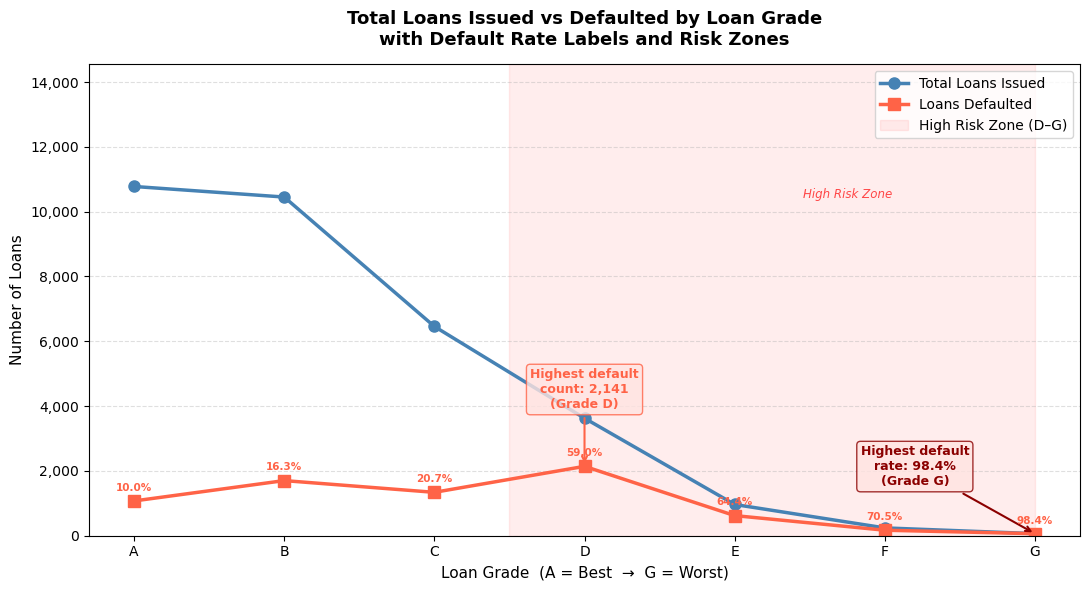

Done!


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Load data ─────────────────────────────────────────────────────────────────
path = kagglehub.dataset_download("laotse/credit-risk-dataset")
print("Dataset downloaded to:", path)

files = os.listdir(path)
print("Available files:", files)

csv_file = os.path.join(path, files[0])
df = pd.read_csv(csv_file)

grade_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G']

total        = df.groupby('loan_grade')['loan_amnt'].count().reindex(grade_order)
defaulted    = df[df['loan_status'] == 1].groupby('loan_grade')['loan_amnt'].count().reindex(grade_order)
default_rate = (defaulted / total * 100).round(1)

# ── Key points to annotate ────────────────────────────────────────────────────
max_count_grade = defaulted.idxmax()          # D  — highest raw default count
max_count_val   = defaulted.max()             # 2141
max_rate_grade  = default_rate.idxmax()       # G  — highest default rate (98.4%)
max_rate_val    = default_rate.max()          # 98.4

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(grade_order, total,
        marker='o', color='steelblue', linewidth=2.5,
        markersize=8, label='Total Loans Issued')

ax.plot(grade_order, defaulted,
        marker='s', color='tomato', linewidth=2.5,
        markersize=8, label='Loans Defaulted')

# ── Annotation 1: Max default COUNT (Grade D) ─────────────────────────────────
ax.annotate(
    f'Highest default\ncount: {max_count_val:,}\n(Grade {max_count_grade})',
    xy=(max_count_grade, max_count_val),
    xytext=(max_count_grade, max_count_val + 1800),
    fontsize=9, color='tomato', fontweight='bold',
    ha='center',
    arrowprops=dict(arrowstyle='->', color='tomato', lw=1.5),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='mistyrose', edgecolor='tomato', alpha=0.8)
)

# ── Annotation 2: Max default RATE (Grade G) ──────────────────────────────────
ax.annotate(
    f'Highest default\nrate: {max_rate_val}%\n(Grade {max_rate_grade})',
    xy=(max_rate_grade, defaulted[max_rate_grade]),
    xytext=(5.2, defaulted[max_rate_grade] + 1500),
    fontsize=9, color='darkred', fontweight='bold',
    ha='center',
    arrowprops=dict(arrowstyle='->', color='darkred', lw=1.5),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='mistyrose', edgecolor='darkred', alpha=0.8)
)

# ── Shaded danger zone (grades D–G) ──────────────────────────────────────────
ax.axvspan(2.5, 6, alpha=0.07, color='red', label='High Risk Zone (D–G)')
ax.text(4.75, ax.get_ylim()[1] * 0.92 if ax.get_ylim()[1] > 0 else 9500,
        'High Risk Zone', fontsize=8.5, color='red', alpha=0.7,
        ha='center', style='italic')

# ── Default rate labels on the defaulted line ────────────────────────────────
for i, grade in enumerate(grade_order):
    ax.text(i, defaulted[grade] + 250,
            f'{default_rate[grade]}%',
            ha='center', va='bottom', fontsize=7.5,
            color='tomato', fontweight='bold')

# ── Formatting ────────────────────────────────────────────────────────────────
ax.set_title('Total Loans Issued vs Defaulted by Loan Grade\n'
             'with Default Rate Labels and Risk Zones',
             fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Loan Grade  (A = Best  →  G = Worst)', fontsize=11)
ax.set_ylabel('Number of Loans', fontsize=11)
ax.legend(fontsize=10, loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_ylim(0, total.max() * 1.35)

plt.tight_layout()
plt.show()
print("Done!")
